In [2]:
import numpy as np
import matplotlib.pyplot as plt

[[2.40802765e-05 5.08300000e-01 1.17300000e-01 0.00000000e+00]
 [5.00566959e-01 5.04400000e-01 1.18300000e-01 0.00000000e+00]
 [1.00120759e+00 5.00500000e-01 1.18300000e-01 0.00000000e+00]
 ...
 [6.99331452e+02 5.78700000e-01 2.28700000e-01 0.00000000e+00]
 [6.99832078e+02 5.78700000e-01 2.29700000e-01 0.00000000e+00]
 [7.00332765e+02 5.78700000e-01 2.29700000e-01 0.00000000e+00]]


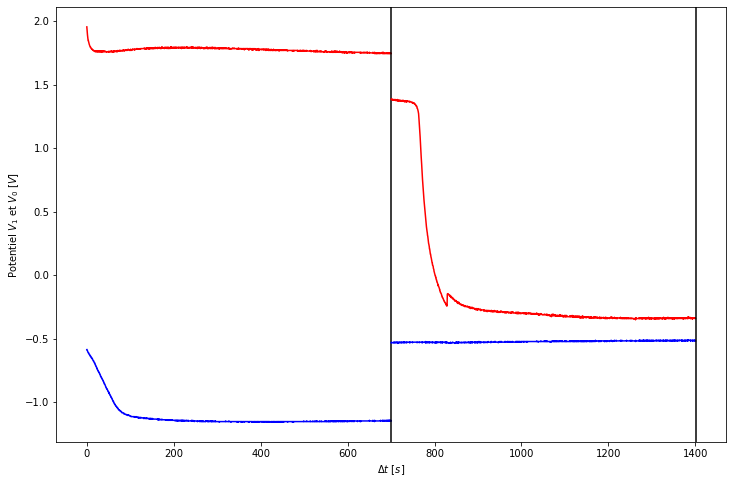

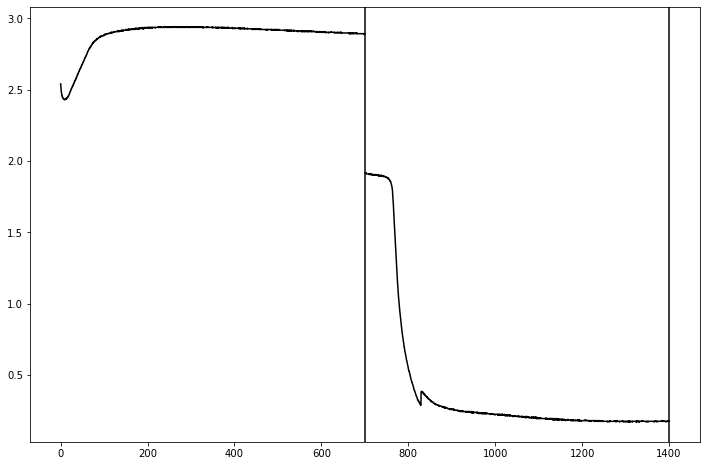

In [12]:
files = "2023-10-25/20mA-Gene+ResistanceVariable/Donnee_C3.csv", "2023-10-25/20mA-Gene+ResistanceVariable/Donnee_D2.csv"
dtype = 'C', 'D'


def get_tensions(V0 : 'V', V1 : 'V', V2 : 'V', dtype = 'C') : 
    #if dtype == 'C' : 
    return 5*(V2-V1), 5*(V0-V1)
        #return V1-V0, V1
        #return V1-V0, V1
    #elif dtype == 'D' : 
    #    return V0-V1, V2-V1
        #return -V1, V0-V1
    #else : 
    #    raise ValueError
        
data = [np.loadtxt(files[n], delimiter = ";", skiprows = 1) for n in range(len(files)) ]

print(data[0])

data[1][:,0] += data[0][-1,0]

fig = plt.figure(figsize = (12,8))
ax = fig.subplots()
for n in range(len(data)) : 
    t = data[n][:,0]
    V0 = data[n][:,1]
    V1 = data[n][:,2]
    V2 = data[n][:,3]
    
    UPb, UPbO2 = get_tensions(V0, V1, V2, dtype = dtype[n])
    
    plt.plot(data[n][:,0], UPbO2, color = 'red') #PbO2
    plt.plot(data[n][:,0], UPb, color = 'blue') #Pb
    ax.axvline(x=data[n][-1,0], color = 'black')

ax.set_xlabel("$\Delta t$ [$s$]")
ax.set_ylabel("Potentiel $V_1$ et $V_0$ [$V$]")

fig = plt.figure(figsize = (12,8))
ax = fig.subplots()
for n in range(len(data)) : 
    
    t = data[n][:,0]
    V0 = data[n][:,1]
    V1 = data[n][:,2]
    V2 = data[n][:,3]
    
    UPb, UPbO2 = get_tensions(V0, V1, V2, dtype = dtype[n])
    
    plt.plot(data[n][:,0], np.absolute(UPbO2-UPb), color = 'black')
    ax.axvline(x=data[n][-1,0], color = 'black')